# Test suite — `agop-eigen-alignment`

A sandbox that exercises everything in `src/` against ground truth implementations in JAX.

Contents:

0. Setup and a tiny check harness
1. `poly` and `hermite` — including the **two usage modes** and monomial→Hermite conversion
2. **Ground-truth AGOP** of a multi-index target (empirical and closed form)
3. Linear-algebra primitives — `stiefel`, `compute_topk_eigs`, `mvp_power_iteration`, `align_bases`
4. Autodiff operators — HVP, NTK MVP, AGOP
5. Parametrization and a parametrization-aware `eta_crit`
6. End-to-end smoke test

## 0. Setup

In [ ]:
import os, sys, math
sys.path.insert(1, os.path.abspath(os.path.join('..', 'src')))

import jax

import numpy as np
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt

from functools import partial
from jax.flatten_util import ravel_pytree
from numpy.polynomial import hermite_e as npHe

from utils import RNGKey
from linalg import (stiefel, compute_topk_eigs, mvp_power_iteration, align_bases,
                    matrix_cosine, perm_hamming, kendall_tau,
                    spectral_l2, spectral_kl, wasserstein_1d)
from poly import poly, hermite
from multi_index import generate_multi_index_data
from networks import MLP
from opt import TrainState, gd_update, train_step, batch_loss
from agop import agop, compute_agop, compute_agop_eigs, compute_nfm, compute_nfm_eigs
from ntk import nvp
from hess import _hvp_flat
from optax import l2_loss

jax.config.update('jax_platform_name', 'cpu')
print(jax.__version__, jax.devices())

Neural Tangents library not found. Using only custom NTK implementation.
0.9.2 [CpuDevice(id=0)]


In [2]:
# ---- tiny check harness -------------------------------------------------
_RESULTS = []

def check(name, err, tol, higher_is_better=False):
    """Record and print a numeric check.  err is the measured quantity, tol the bound."""
    ok = (err >= tol) if higher_is_better else (err <= tol)
    _RESULTS.append((name, ok, float(err), float(tol)))
    rel = ">=" if higher_is_better else "<="
    print(f"  [{'PASS' if ok else 'FAIL'}] {name:52s} {err:11.3e} {rel} {tol:.0e}")
    return ok

def summary():
    n = len(_RESULTS); bad = [r for r in _RESULTS if not r[1]]
    print(f"\n{'='*72}\n{n - len(bad)}/{n} passed")
    for nm, _, e, t in bad:
        print(f"  FAILED: {nm}  ({e:.3e} vs {t:.0e})")
    return not bad

## 1. `poly` and `hermite`

### 1.1 `hermite` is a *basis* builder

Despite the name, `hermite(k, x)` returns the whole basis, shape `(k+1, *x.shape)`, with
`out[j] = He_j(x)`. `normalize=True` gives the **orthonormal** basis
$h_j = He_j/\sqrt{j!}$, for which $\mathbb{E}_{z\sim N(0,1)}[h_i h_j] = \delta_{ij}$.

In [3]:
print("shape check")
x = jnp.linspace(-3, 3, 7)
H = hermite(4, x)
print(f"  hermite(4, x) with x.shape={x.shape} -> {H.shape}   (k+1 rows)")
print(f"  hermite(4, 2.0)                      -> {hermite(4, 2.0).shape}")

print("\nagainst numpy.polynomial.hermite_e (unnormalized)")
xs = np.array([0.0, 0.5, 1.0, 2.0, -1.5, 3.7])
H = np.asarray(hermite(10, jnp.asarray(xs)))
worst = 0.0
for k in range(11):
    c = np.zeros(k + 1); c[k] = 1.0
    ref = npHe.hermeval(xs, c)
    worst = max(worst, (np.abs(H[k] - ref) / (np.abs(ref) + 1e-9)).max())
# RELATIVE error: He_10 reaches ~1e4, so float32 absolute error is ~1e-3 by construction
check("hermite matches numpy hermeval, k<=10 (relative)", worst, 1e-5)

shape check
  hermite(4, x) with x.shape=(7,) -> (5, 7)   (k+1 rows)
  hermite(4, 2.0)                      -> (5,)

against numpy.polynomial.hermite_e (unnormalized)


  [PASS] hermite matches numpy hermeval, k<=10 (relative)       3.328e-07 <= 1e-05


np.True_

In [4]:
print("orthonormality of the normalized basis under N(0,1)")
rng = RNGKey(0)
zs = jr.normal(rng.next(), (400_000,)).astype(jnp.float64) \
     if jax.config.jax_enable_x64 else jr.normal(rng.next(), (400_000,))
K = 3   # float32 + MC variance make K>3 noisy; the point is orthonormality, not high degree
Hn = hermite(K, zs, normalize=True)          # (K+1, n)
G = (Hn @ Hn.T) / zs.shape[0]                # should be I
check("E[h_i h_j] = delta_ij  (MC, n=4e5)", float(jnp.abs(G - jnp.eye(K + 1)).max()), 5e-2)
print("\n  Gram matrix (want identity):")
print(np.round(np.asarray(G), 3))

orthonormality of the normalized basis under N(0,1)


  [PASS] E[h_i h_j] = delta_ij  (MC, n=4e5)                     1.878e-02 <= 5e-02

  Gram matrix (want identity):
[[ 1.     0.003 -0.002  0.   ]
 [ 0.003  0.998  0.005 -0.004]
 [-0.002  0.005  0.994  0.006]
 [ 0.    -0.004  0.006  0.981]]


### 1.2 Mode 1 — per-coordinate orders

This is what `poly` does today:

$$g(z) \;=\; \sum_k c_k \, P_{o_k}(z_k)$$

Coefficient $k$ and order $k$ both attach to **coordinate $k$**. `coeffs`, `orders` and the
used part of `z` all have the same length.

In [5]:
coeffs = jnp.array([4.0, 3.0, 2.0])
orders = jnp.array([3, 2, 1])
z      = jnp.array([1.5, -0.5, 2.0])

got  = float(poly(coeffs, orders, z, basis="monic"))
want = 4.0*1.5**3 + 3.0*(-0.5)**2 + 2.0*2.0        # c_k * z_k ** o_k
print(f"  monic : poly={got:.6f}  hand={want:.6f}")
check("mode 1, monic basis", abs(got - want), 1e-5)

Hz   = np.asarray(hermite(3, z))
got  = float(poly(coeffs, orders, z, basis="hermite"))
want = 4.0*Hz[3,0] + 3.0*Hz[2,1] + 2.0*Hz[1,2]     # c_k * He_{o_k}(z_k)
print(f"  hermite: poly={got:.6f}  hand={want:.6f}")
check("mode 1, hermite basis", abs(got - want), 1e-5)

# padding: z longer than orders -> the extra coordinates get coeff 0, order 0
z5   = jnp.array([1.5, -0.5, 2.0, 9.0, -9.0])
want_monic = 4.0*1.5**3 + 3.0*(-0.5)**2 + 2.0*2.0
got5 = float(poly(coeffs, orders, z5, basis="monic"))
print(f"\n  z longer than orders: poly={got5:.6f}  (unpadded {want_monic:.6f})")
check("mode 1 padding leaves the value unchanged (monic)", abs(got5 - want_monic), 1e-4)

  monic : poly=18.250000  hand=18.250000
  [PASS] mode 1, monic basis                                    0.000e+00 <= 1e-05


  hermite: poly=-2.750000  hand=-2.750000
  [PASS] mode 1, hermite basis                                  0.000e+00 <= 1e-05



  z longer than orders: poly=18.250000  (unpadded 18.250000)
  [PASS] mode 1 padding leaves the value unchanged (monic)      0.000e+00 <= 1e-04


True

### 1.3 Mode 2 — one polynomial applied coordinate-wise

The second usage: a **single** univariate polynomial $p$, defined by `(coeffs, orders)`,
applied to **every** coordinate of $z$:

$$p(t) \;=\; \sum_k c_k\, P_{o_k}(t), \qquad g(z) \;=\; \sum_{j} p(z_j)$$

Here `coeffs`/`orders` index the *terms of $p$*, not the coordinates — so their length is
unrelated to $\dim z$. `poly` does **not** currently support this; below is a reference
implementation for the notebook only.

In [6]:
def poly_coordwise(coeffs, orders, z, basis="monic", normalize=False, reduce="sum"):
    """Apply ONE univariate polynomial p(t) = sum_k coeffs[k] P_{orders[k]}(t)
    to every coordinate of z.

    reduce="sum"  -> scalar  sum_j p(z_j)          (an additive multi-index link)
    reduce="none" -> vector  [p(z_0), ..., p(z_d)] (useful for plotting / diagnostics)

    Contrast with poly(), where coeffs[k]/orders[k] attach to coordinate k.
    Here they index the TERMS of p, so len(coeffs) is unrelated to len(z).
    """
    coeffs = jnp.asarray(coeffs)
    orders = jnp.asarray(orders)
    z      = jnp.asarray(z)
    assert coeffs.shape == orders.shape, "coeffs and orders index the terms of p"

    if basis == "monic":
        vals = coeffs @ (z[None, :] ** orders.astype(jnp.int32)[:, None])   # (d,)
    elif basis == "hermite":
        p = orders.astype(jnp.int32)
        H = hermite(int(jnp.max(p)), z, normalize=normalize)                 # (K+1, d)
        vals = coeffs @ H[p]                                                # (d,)
    else:
        raise ValueError(f"Unknown basis {basis!r}")

    return jnp.sum(vals) if reduce == "sum" else vals


# p(t) = 4 t^3 + 3 t^2 + 2 t, applied to each coordinate
c2, o2 = jnp.array([4.0, 3.0, 2.0]), jnp.array([3, 2, 1])
z      = jnp.array([1.5, -0.5, 2.0])
p      = lambda t: 4.0*t**3 + 3.0*t**2 + 2.0*t

vec  = np.asarray(poly_coordwise(c2, o2, z, reduce="none"))
want = np.array([p(float(t)) for t in z])
print(f"  per-coordinate p(z_j): {np.round(vec,5)}")
print(f"  hand                 : {np.round(want,5)}")
check("mode 2, monic, reduce='none'", np.abs(vec - want).max(), 1e-4)
check("mode 2, monic, reduce='sum'",
      abs(float(poly_coordwise(c2, o2, z)) - want.sum()), 1e-4)

# hermite flavour, and independence from dim(z)
for d_try in (3, 5, 8):
    zz = jr.normal(RNGKey(1).next(), (d_try,))
    H  = np.asarray(hermite(3, zz))
    w  = float(sum(4.0*H[3,j] + 3.0*H[2,j] + 2.0*H[1,j] for j in range(d_try)))
    g  = float(poly_coordwise(c2, o2, zz, basis="hermite"))
    print(f"  d={d_try}: coordwise hermite got {g:10.5f}  hand {w:10.5f}")
    check(f"mode 2, hermite, d={d_try}", abs(g - w), 1e-3)

  per-coordinate p(z_j): [23.25 -0.75 48.  ]
  hand                 : [23.25 -0.75 48.  ]
  [PASS] mode 2, monic, reduce='none'                           0.000e+00 <= 1e-04
  [PASS] mode 2, monic, reduce='sum'                            0.000e+00 <= 1e-04


  d=3: coordwise hermite got   -0.01427  hand   -0.01427
  [PASS] mode 2, hermite, d=3                                   4.768e-07 <= 1e-03


  d=5: coordwise hermite got    1.65985  hand    1.65985
  [PASS] mode 2, hermite, d=5                                   4.768e-07 <= 1e-03


  d=8: coordwise hermite got    8.91726  hand    8.91726
  [PASS] mode 2, hermite, d=8                                   0.000e+00 <= 1e-03


**The two modes differ** — mode 1 gives each coordinate its own single term; mode 2 gives
every coordinate the same multi-term polynomial. They coincide only when $p$ has one term
and $\dim z = 1$.

In [7]:
z = jnp.array([1.5, -0.5, 2.0])
m1 = float(poly(c2, o2, z, basis="monic"))
m2 = float(poly_coordwise(c2, o2, z, basis="monic"))
print(f"  mode 1 (per-coordinate orders) : {m1:.5f}   = 4 z0^3 + 3 z1^2 + 2 z2")
print(f"  mode 2 (p applied coordinate-wise): {m2:.5f}   = p(z0) + p(z1) + p(z2)")
check("modes 1 and 2 are genuinely different", abs(m1 - m2), 1e-3, higher_is_better=True)

  mode 1 (per-coordinate orders) : 18.25000   = 4 z0^3 + 3 z1^2 + 2 z2
  mode 2 (p applied coordinate-wise): 70.50000   = p(z0) + p(z1) + p(z2)
  [PASS] modes 1 and 2 are genuinely different                  5.225e+01 >= 1e-03


True

### 1.4 Monomial → Hermite conversion

The identity

$$z^p \;=\; \sum_{j=0}^{\lfloor p/2\rfloor} \frac{p!}{j!\,2^j\,(p-2j)!}\; He_{p-2j}(z)$$

is what tells you a target's true **information exponent**: the lowest nonzero Hermite degree.
This is why `orders=[3,2,1]` is *not* a difficulty staircase — $z^3$ contains $He_1$.

In [8]:
def monomial_to_hermite(p, normalized=False):
    """Hermite coefficients of z**p.  Returns {degree: coefficient}.

    z^p = sum_j  p! / (j! 2^j (p-2j)!)  He_{p-2j}(z)

    normalized=True gives coefficients in the orthonormal basis h_m = He_m/sqrt(m!),
    i.e. multiplies each by sqrt(m!).
    """
    out = {}
    for j in range(p // 2 + 1):
        m = p - 2 * j
        c = math.factorial(p) / (math.factorial(j) * 2**j * math.factorial(m))
        out[m] = c * (math.sqrt(math.factorial(m)) if normalized else 1.0)
    return out


def poly_to_hermite(coeffs, orders, normalized=False):
    """Hermite expansion of a univariate polynomial sum_k coeffs[k] z**orders[k]."""
    out = {}
    for c, p in zip(np.asarray(coeffs).tolist(), np.asarray(orders).astype(int).tolist()):
        for m, hc in monomial_to_hermite(p, normalized).items():
            out[m] = out.get(m, 0.0) + c * hc
    return {m: v for m, v in sorted(out.items()) if abs(v) > 1e-12}


def information_exponent(coeffs, orders):
    """Lowest nonzero Hermite degree > 0."""
    h = poly_to_hermite(coeffs, orders)
    nz = [m for m, v in h.items() if m > 0 and abs(v) > 1e-12]
    return min(nz) if nz else math.inf


print("monomial expansions")
for p in range(1, 5):
    exp = monomial_to_hermite(p)
    ref = npHe.poly2herme(np.eye(p + 1)[p])
    got = np.zeros(p + 1)
    for m, v in exp.items(): got[m] = v
    print(f"  z^{p} = " + "  +  ".join(f"{v:g}*He_{m}" for m, v in exp.items()))
    check(f"z^{p} -> Hermite matches numpy poly2herme", np.abs(got - ref).max(), 1e-9)

monomial expansions
  z^1 = 1*He_1
  [PASS] z^1 -> Hermite matches numpy poly2herme                0.000e+00 <= 1e-09
  z^2 = 1*He_2  +  1*He_0
  [PASS] z^2 -> Hermite matches numpy poly2herme                0.000e+00 <= 1e-09
  z^3 = 1*He_3  +  3*He_1
  [PASS] z^3 -> Hermite matches numpy poly2herme                0.000e+00 <= 1e-09
  z^4 = 1*He_4  +  6*He_2  +  3*He_0
  [PASS] z^4 -> Hermite matches numpy poly2herme                0.000e+00 <= 1e-09


In [9]:
print("the target actually used in the experiments")
print("  g(z) = 4 z1^3 + 3 z2^2 + 2 z3   (mode 1: one monomial per coordinate)\n")
for name, c, p in [("direction 1", 4.0, 3), ("direction 2", 3.0, 2), ("direction 3", 2.0, 1)]:
    h  = poly_to_hermite([c], [p])
    ie = information_exponent([c], [p])
    print(f"  {name}: {c}*z^{p} = " + " + ".join(f"{v:g} He_{m}" for m, v in h.items())
          + f"    -> information exponent {ie}")
print("\n  => per-direction information exponents are (1, 2, 1), NOT (3, 2, 1).")
print("     Direction 1's He_1 coefficient is 12 -- the LARGEST linear term in the target,")
print("     so the direction that looks hardest is learned first.")
check("direction 1 has information exponent 1 (not 3)",
      abs(information_exponent([4.0], [3]) - 1), 1e-9)

the target actually used in the experiments
  g(z) = 4 z1^3 + 3 z2^2 + 2 z3   (mode 1: one monomial per coordinate)

  direction 1: 4.0*z^3 = 12 He_1 + 4 He_3    -> information exponent 1
  direction 2: 3.0*z^2 = 3 He_0 + 3 He_2    -> information exponent 2
  direction 3: 2.0*z^1 = 2 He_1    -> information exponent 1

  => per-direction information exponents are (1, 2, 1), NOT (3, 2, 1).
     Direction 1's He_1 coefficient is 12 -- the LARGEST linear term in the target,
     so the direction that looks hardest is learned first.
  [PASS] direction 1 has information exponent 1 (not 3)         0.000e+00 <= 1e-09


True

### 1.5 Verify a Hermite-basis target *is* what it claims

Build $g$ in the orthonormal Hermite basis and check the two exact identities:
$\mathbb{E}[g^2] = \sum_k c_k^2$ and, per direction, information exponent $= p_k$.

In [10]:
ps = jnp.array([3, 2, 1]); cs = jnp.array([1.0, 1.3, 0.7])
g_herm = lambda z: poly(cs, ps, z, basis="hermite", normalize=True)

rng = RNGKey(2)
Z = jr.normal(rng.next(), (200_000, 3))
vals = jax.vmap(g_herm)(Z)
print(f"  E[g^2] empirical = {float(jnp.mean(vals**2)):.5f}")
print(f"  sum c_k^2        = {float(jnp.sum(cs**2)):.5f}")
check("E[g^2] = sum c_k^2 for an orthonormal Hermite target",
      abs(float(jnp.mean(vals**2)) - float(jnp.sum(cs**2))), 3e-2)
print(f"  E[g]             = {float(jnp.mean(vals)):.5f}   (0 when no He_0 term)")

  E[g^2] empirical = 3.18199
  sum c_k^2        = 3.18000
  [PASS] E[g^2] = sum c_k^2 for an orthonormal Hermite target   1.992e-03 <= 3e-02
  E[g]             = 0.00512   (0 when no He_0 term)


### 1.6 Converting a **multi-index** target into the Hermite basis

A mode-1 target $g(z)=\sum_k c_k z_k^{p_k}$ is *additive*, so it converts coordinate-by-coordinate
into a table $a[m,j]$ of orthonormal-Hermite coefficients:

$$g(z) \;=\; \sum_{j}\sum_{m} a[m,j]\; h_m(z_j)$$

This conversion is what reveals the target's true per-direction information exponents.

In [11]:
def multi_index_to_hermite(coeffs, orders, normalized=True):
    # Hermite coefficient table a[m, j] for the additive target
    #     g(z) = sum_j coeffs[j] * z_j ** orders[j]
    # Returns (table, K) with table.shape == (K+1, r):
    #     table[m, j] = coefficient of h_m(z_j)
    coeffs = np.asarray(coeffs, dtype=float)
    orders = np.asarray(orders).astype(int)
    K = int(orders.max())
    tab = np.zeros((K + 1, len(orders)))
    for j, (c, p) in enumerate(zip(coeffs, orders)):
        for mdeg, hc in monomial_to_hermite(int(p), normalized).items():
            tab[mdeg, j] += c * hc
    return tab, K


def hermite_table_eval(tab, z, normalized=True):
    # Evaluate g(z) = sum_{m,j} tab[m,j] h_m(z_j) for z of shape (..., r)
    K = tab.shape[0] - 1
    H = hermite(K, jnp.asarray(z).T, normalize=normalized)   # (K+1, r, ...)
    return jnp.einsum('mj,mj...->...', jnp.asarray(tab), H)


cf, od = [4.0, 3.0, 2.0], [3, 2, 1]
tab, Kt = multi_index_to_hermite(cf, od)
print('  g(z) = 4 z1^3 + 3 z2^2 + 2 z3  ->  orthonormal-Hermite table a[m, j]')
print('         rows = Hermite degree m, cols = coordinate j')
print(np.round(tab, 4))

ie = [int(min(m for m in range(1, Kt + 1) if abs(tab[m, j]) > 1e-9)) for j in range(len(od))]
print(f'\n  per-coordinate information exponents: {ie}   (the ORDERS were {od})')
check('converted target has information exponents (1,2,1)',
      float(np.abs(np.array(ie) - np.array([1, 2, 1])).max()), 1e-9)

  g(z) = 4 z1^3 + 3 z2^2 + 2 z3  ->  orthonormal-Hermite table a[m, j]
         rows = Hermite degree m, cols = coordinate j
[[ 0.      3.      0.    ]
 [12.      0.      2.    ]
 [ 0.      4.2426  0.    ]
 [ 9.798   0.      0.    ]]

  per-coordinate information exponents: [1, 2, 1]   (the ORDERS were [3, 2, 1])
  [PASS] converted target has information exponents (1,2,1)     0.000e+00 <= 1e-09


True

In [12]:
print('round trip: does the Hermite form reproduce the original function?')
rngc = RNGKey(9)
Zc = jr.normal(rngc.next(), (20_000, 3))
orig = jax.vmap(lambda z: poly(jnp.array(cf), jnp.array(od), z, basis='monic'))(Zc)
conv = hermite_table_eval(tab, Zc)
err = float(jnp.abs(orig - conv).max() / jnp.abs(orig).max())
print(f'  max relative difference over 20k samples = {err:.3e}')
check('Hermite conversion reproduces the original target', err, 1e-4)

round trip: does the Hermite form reproduce the original function?


  max relative difference over 20k samples = 1.173e-07
  [PASS] Hermite conversion reproduces the original target      1.173e-07 <= 1e-04


True

### 1.7 Exact AGOP from a Hermite table

For $g(z)=\sum_j \sum_m a[m,j]\,h_m(z_j)$, using $h_m' = \sqrt{m}\,h_{m-1}$ and
$\mathbb{E}[h_i h_j]=\delta_{ij}$:

$$A_{jj} = \sum_m a[m,j]^2\, m, \qquad A_{jk} = a[1,j]\,a[1,k]\;\;(j\neq k)$$

The off-diagonal involves **only the degree-1 coefficients**, since $\mathbb{E}[h_{m-1}]=0$
unless $m=1$. That is precisely why two information-exponent-1 directions couple.

In [13]:
def hermite_table_A(tab):
    # Exact latent AGOP A = E_z[grad g grad g^T] from a Hermite coefficient table
    K, rr = tab.shape[0] - 1, tab.shape[1]
    A = np.zeros((rr, rr))
    for j in range(rr):
        A[j, j] = sum(tab[m, j] ** 2 * m for m in range(K + 1))
    for j in range(rr):
        for k in range(rr):
            if j != k:
                A[j, k] = tab[1, j] * tab[1, k]
    return A


A_pred = hermite_table_A(tab)
print('  predicted A from the Hermite table:')
print(np.round(A_pred, 2))

grad = jax.vmap(jax.grad(lambda z: poly(jnp.array(cf), jnp.array(od), z, basis='monic')))(Zc)
A_emp = np.asarray(grad.T @ grad / Zc.shape[0])
print('\n  empirical A (Monte Carlo, 20k samples):')
print(np.round(A_emp, 2))
rel = np.linalg.norm(A_pred - A_emp) / np.linalg.norm(A_pred)
print(f'\n  relative error = {rel:.3e}')
check('closed-form A from the Hermite table matches MC', rel, 5e-2)

print('\n  A[0,2] = A[2,0] = 24 != 0: directions 1 and 3 BOTH have information exponent 1,')
print('  so their gradients share a constant component and couple. The rows of U are')
print('  therefore NOT the eigenvectors of G*, which caps align_bases(., U.T) below 1.')

  predicted A from the Hermite table:
[[432.   0.  24.]
 [  0.  36.   0.]
 [ 24.   0.   4.]]



  empirical A (Monte Carlo, 20k samples):
[[ 4.2614e+02 -2.3000e-01  2.3820e+01]
 [-2.3000e-01  3.5520e+01 -9.0000e-02]
 [ 2.3820e+01 -9.0000e-02  4.0000e+00]]

  relative error = 1.355e-02
  [PASS] closed-form A from the Hermite table matches MC        1.355e-02 <= 5e-02

  A[0,2] = A[2,0] = 24 != 0: directions 1 and 3 BOTH have information exponent 1,
  so their gradients share a constant component and couple. The rows of U are
  therefore NOT the eigenvectors of G*, which caps align_bases(., U.T) below 1.


## 2. Ground-truth AGOP of the target

For $f^*(x) = g(Ux)$ with $x\sim N(0,I_d)$ and $U$ having orthonormal rows,

$$G^\star \;=\; \mathbb{E}\!\left[\nabla f^* \nabla f^{*\top}\right] \;=\; U^\top A\, U,
\qquad A \;=\; \mathbb{E}_z\!\left[\nabla g\, \nabla g^\top\right]$$

so $G^\star$ has rank $\le r$ and its eigenvectors live in the index subspace. **This is the
reference the learned AGOP should converge to** — and note it is *not* generally $U$ itself.

In [14]:
def target_agop_empirical(f, X):
    """(1/n) sum_i grad f(x_i) grad f(x_i)^T -- same estimator as agop() in src/."""
    J = jax.vmap(jax.grad(f))(X)
    return J.T @ J / X.shape[0]

### 2.1 Closed form for an **additive orthonormal-Hermite** target

With $g(z)=\sum_k c_k h_{p_k}(z_k)$ and $h_k' = \sqrt{k}\,h_{k-1}$:

$$A \;=\; \operatorname{diag}\!\left(c_k^2 p_k\right) \;+\; mm^\top - \operatorname{diag}(m)^2,
\qquad m_k = c_k\,\mathbb{1}[p_k = 1]$$

The rank-one term appears because every $p_k{=}1$ direction contributes a **constant**
$c_k h_0$ to its gradient, and those add coherently. Consequence: if two directions have
information exponent 1 they are **not individually identifiable** from the AGOP.

In [15]:
def hermite_target_A(coeffs, exps):
    """Exact latent-space AGOP A = E_z[grad g grad g^T] for an additive
    orthonormal-Hermite target g(z) = sum_k c_k h_{p_k}(z_k)."""
    c = np.asarray(coeffs, dtype=float); p = np.asarray(exps, dtype=float)
    A = np.diag(c**2 * p)
    m = np.where(p == 1, c, 0.0)
    return A + np.outer(m, m) - np.diag(m**2)


print("no p=1 direction: A should be exactly diagonal")
ps_a, cs_a = [4, 3, 2], [0.9, 1.1, 0.7]
A = hermite_target_A(cs_a, ps_a)
print(np.round(A, 4))
check("A diagonal when no direction has exponent 1",
      np.abs(A - np.diag(np.diag(A))).max(), 1e-12)
check("A_kk = c_k^2 p_k",
      np.abs(np.diag(A) - np.array(cs_a)**2 * np.array(ps_a)).max(), 1e-12)

print("\ntwo p=1 directions: rank-one coupling appears")
A2 = hermite_target_A([1.0, 1.3, 0.7], [3, 1, 1])
print(np.round(A2, 4))
check("off-diagonal coupling between the two p=1 directions",
      abs(A2[1, 2]), 1e-6, higher_is_better=True)

no p=1 direction: A should be exactly diagonal
[[3.24 0.   0.  ]
 [0.   3.63 0.  ]
 [0.   0.   0.98]]
  [PASS] A diagonal when no direction has exponent 1            0.000e+00 <= 1e-12
  [PASS] A_kk = c_k^2 p_k                                       0.000e+00 <= 1e-12

two p=1 directions: rank-one coupling appears
[[3.   0.   0.  ]
 [0.   1.69 0.91]
 [0.   0.91 0.49]]
  [PASS] off-diagonal coupling between the two p=1 directions   9.100e-01 >= 1e-06


np.True_

In [16]:
print("closed form vs Monte Carlo")
rng = RNGKey(3)
d, r = 6, 3
X = jr.normal(rng.next(), (200_000, d))
U = stiefel(d, r, rng)

ps_t = jnp.array([3, 2, 1]); cs_t = jnp.array([1.0, 1.3, 0.7])
f_star = lambda x: poly(cs_t, ps_t, U @ x, basis="hermite", normalize=True)

G_emp  = np.asarray(target_agop_empirical(f_star, X))
A_hat  = hermite_target_A(np.asarray(cs_t), np.asarray(ps_t))
G_pred = np.asarray(U).T @ A_hat @ np.asarray(U)

print(f"  ||G_emp - G_pred||_F / ||G_pred||_F = "
      f"{np.linalg.norm(G_emp-G_pred)/np.linalg.norm(G_pred):.3e}")
check("closed-form G* matches Monte Carlo",
      np.linalg.norm(G_emp - G_pred) / np.linalg.norm(G_pred), 3e-2)

w_emp  = np.sort(np.linalg.eigvalsh(G_emp))[::-1][:r]
w_pred = np.sort(np.linalg.eigvalsh(G_pred))[::-1][:r]
print(f"  empirical  spectrum: {np.round(w_emp, 4)}")
print(f"  predicted  spectrum: {np.round(w_pred, 4)}   (= c_k^2 p_k)")
print(f"  rank(G*) = {int((np.linalg.eigvalsh(G_emp) > 1e-6*w_emp[0]).sum())}  (want <= r = {r})")

closed form vs Monte Carlo


  ||G_emp - G_pred||_F / ||G_pred||_F = 7.084e-03
  [PASS] closed-form G* matches Monte Carlo                     7.084e-03 <= 3e-02
  empirical  spectrum: [3.3505 2.9901 0.49  ]
  predicted  spectrum: [3.38 3.   0.49]   (= c_k^2 p_k)
  rank(G*) = 3  (want <= r = 3)


### 2.2 The alignment **ceiling**

`align_bases(G*-eigvecs, U.T)` is bounded above by a value fixed by the target, *before any
training*. When $A$ is diagonal the ceiling is 1; when two directions share exponent 1 it is not.
Compare any measured `AGOP -> U` against this, not against 1.

In [17]:
def alignment_ceiling(coeffs, exps):
    """Best achievable align_bases(., U.T) score for this target."""
    A = hermite_target_A(coeffs, exps)
    w, V = np.linalg.eigh(A); V = V[:, ::-1]
    W = (np.eye(len(exps)).T @ V) ** 2
    from scipy.optimize import linear_sum_assignment
    ri, ci = linear_sum_assignment(-W)
    return W[ri, ci].mean()

for nm, c, p in [("[4,3,2] equal c        ", [1/np.sqrt(3)]*3, [4, 3, 2]),
                 ("[3,2,1] equal c        ", [1/np.sqrt(3)]*3, [3, 2, 1]),
                 ("[3,1,1] TWO exponent-1 ", [1.0, 1.3, 0.7],  [3, 1, 1])]:
    print(f"  {nm}: ceiling = {alignment_ceiling(c, p):.6f}")
check("ceiling is 1 when at most one direction has exponent 1",
      abs(alignment_ceiling([1/np.sqrt(3)]*3, [4,3,2]) - 1.0), 1e-6)
check("ceiling is < 1 with two exponent-1 directions",
      1.0 - alignment_ceiling([1.0,1.3,0.7], [3,1,1]), 1e-4, higher_is_better=True)

  [4,3,2] equal c        : ceiling = 1.000000
  [3,2,1] equal c        : ceiling = 1.000000
  [3,1,1] TWO exponent-1 : ceiling = 0.850153
  [PASS] ceiling is 1 when at most one direction has exponent 1   0.000e+00 <= 1e-06
  [PASS] ceiling is < 1 with two exponent-1 directions          1.498e-01 >= 1e-04


np.True_

In [18]:
print("the monic target currently in use: g(z) = 4z1^3 + 3z2^2 + 2z3")
print("  grad g = (12 z1^2, 6 z2, 2)  =>  A = diag/offdiag from E[.]:")
A_monic = np.array([[144*3.0, 0.0, 12*2*1.0],
                    [0.0,     36*1.0, 0.0],
                    [24.0,    0.0,    4.0]])
print(np.round(A_monic, 2))
w = np.linalg.eigvalsh(A_monic)[::-1]
print(f"  normalized spectrum: {np.round(w/w.sum(), 4)}")
W = (np.eye(3).T @ np.linalg.eigh(A_monic)[1][:, ::-1])**2
from scipy.optimize import linear_sum_assignment
ri, ci = linear_sum_assignment(-W)
print(f"  alignment ceiling  : {W[ri,ci].mean():.6f}   <-- compare measured AGOP->U against THIS")

the monic target currently in use: g(z) = 4z1^3 + 3z2^2 + 2z3
  grad g = (12 z1^2, 6 z2, 2)  =>  A = diag/offdiag from E[.]:
[[432.   0.  24.]
 [  0.  36.   0.]
 [ 24.   0.   4.]]
  normalized spectrum: [0.9181 0.0763 0.0056]
  alignment ceiling  : 0.997923   <-- compare measured AGOP->U against THIS


## 3. Linear-algebra primitives

### 3.1 `stiefel`

Note the **shape convention**: `stiefel(m, n, rng)` with `m > n` returns an `(n, m)` matrix with
orthonormal **rows**. Transpose it if you want orthonormal columns.

In [19]:
rng = RNGKey(7)
for (m_, n_) in [(100, 10), (10, 100), (5, 5)]:
    S = stiefel(m_, n_, rng)
    k = min(m_, n_)
    err = float(jnp.abs(S @ S.T - jnp.eye(S.shape[0])).max()) if S.shape[0] <= S.shape[1] \
          else float(jnp.abs(S.T @ S - jnp.eye(S.shape[1])).max())
    print(f"  stiefel({m_:3d},{n_:3d}) -> {str(S.shape):10s}  orthonormality {err:.2e}")
    check(f"stiefel({m_},{n_}) semi-orthogonal", err, 1e-5)

S = stiefel(100, 10, rng)
print(f"\n  stiefel(100, 10).shape = {S.shape}  -> rows are orthonormal; use .T for columns")

  stiefel(100, 10) -> (10, 100)   orthonormality 3.58e-07
  [PASS] stiefel(100,10) semi-orthogonal                        3.576e-07 <= 1e-05
  stiefel( 10,100) -> (100, 10)   orthonormality 2.38e-07
  [PASS] stiefel(10,100) semi-orthogonal                        2.384e-07 <= 1e-05


  stiefel(  5,  5) -> (5, 5)      orthonormality 4.77e-07
  [PASS] stiefel(5,5) semi-orthogonal                           4.768e-07 <= 1e-05

  stiefel(100, 10).shape = (10, 100)  -> rows are orthonormal; use .T for columns


### 3.2 `compute_topk_eigs` — orthogonal iteration vs `eigh`

Ground-truth matrices with **known** spectra. The quantities that matter:
eigenvalue error, **orthonormality** of the returned basis (`align_bases` requires it), and
per-eigenvector overlap with the true eigenvector.

In [20]:
def eig_report(G, k, iters, name, tol_val=1e-3, tol_orth=1e-5):
    d = G.shape[0]
    w, V = jnp.linalg.eigh(G); w, V = w[::-1][:k], V[:, ::-1][:, :k]
    lam, Q = compute_topk_eigs(lambda v: G @ v, d, k, iters, RNGKey(0))
    eerr = float(jnp.abs(lam - w).max() / jnp.abs(w).max())
    oerr = float(jnp.abs(Q.T @ Q - jnp.eye(k)).max())
    ovl  = [round(float(abs(Q[:, i] @ V[:, i])), 4) for i in range(min(k, 5))]
    print(f"  {name:30s} it={iters:4d}  eigval {eerr:9.2e}  orth {oerr:9.2e}  |<q,v>| {ovl}")
    return eerr, oerr

print("A. known spectrum, d=100, k=10")
Qr, _ = jnp.linalg.qr(jr.normal(jr.PRNGKey(11), (100, 100)))
spec  = jnp.linspace(10.0, 0.1, 100)
Gk    = (Qr * spec) @ Qr.T
for it in (3, 30, 100, 300):
    e, o = eig_report(Gk, 10, it, "known spectrum d=100")
check("d=100 k=10 @300 iters: eigenvalues", eig_report(Gk, 10, 300, "(recheck)")[0], 1e-4)
check("d=100 k=10 @300 iters: orthonormality", eig_report(Gk, 10, 300, "(recheck)")[1], 1e-5)

A. known spectrum, d=100, k=10


  known spectrum d=100           it=   3  eigval  1.50e-01  orth  3.58e-07  |<q,v>| [0.5946, 0.154, 0.2171, 0.477, 0.313]
  known spectrum d=100           it=  30  eigval  3.53e-03  orth  4.77e-07  |<q,v>| [0.9998, 0.9993, 0.9996, 0.9883, 0.9889]
  known spectrum d=100           it= 100  eigval  1.47e-04  orth  7.15e-07  |<q,v>| [1.0, 1.0, 1.0, 1.0, 1.0]


  known spectrum d=100           it= 300  eigval  2.19e-06  orth  7.15e-07  |<q,v>| [1.0, 1.0, 1.0, 1.0, 1.0]
  (recheck)                      it= 300  eigval  2.19e-06  orth  7.15e-07  |<q,v>| [1.0, 1.0, 1.0, 1.0, 1.0]
  [PASS] d=100 k=10 @300 iters: eigenvalues                     2.193e-06 <= 1e-04
  (recheck)                      it= 300  eigval  2.19e-06  orth  7.15e-07  |<q,v>| [1.0, 1.0, 1.0, 1.0, 1.0]
  [PASS] d=100 k=10 @300 iters: orthonormality                  7.153e-07 <= 1e-05


True

In [21]:
print("B. k == dim  (the d=3, r=3 setting used in the experiments)")
A3 = jr.normal(jr.PRNGKey(12), (3, 3)); G3 = A3 @ A3.T / 3
for it in (1, 3, 30):
    eig_report(G3, 3, it, "random PSD d=3, k=3")
print("     -> exact regardless of iteration count: Q spans the whole space,")
print("        so Rayleigh-Ritz returns the exact answer immediately.")
e, o = eig_report(G3, 3, 3, "(check)")
check("k == dim is exact", e, 1e-5)

print("\nC. ill-conditioned, like a trained AGOP")
Qc, _ = jnp.linalg.qr(jr.normal(jr.PRNGKey(13), (3, 3)))
Gc = (Qc * jnp.array([1.87, 0.157, 0.0101])) @ Qc.T
for it in (3, 30, 100):
    eig_report(Gc, 3, it, "AGOP-like, cond=185")

print("\nD. rank-deficient (k > rank)")
B = jr.normal(jr.PRNGKey(14), (3, 2)); Gr = B @ B.T / 3
for it in (30, 100):
    eig_report(Gr, 3, it, "rank-2 in d=3")

B. k == dim  (the d=3, r=3 setting used in the experiments)


  random PSD d=3, k=3            it=   1  eigval  6.47e-08  orth  3.58e-07  |<q,v>| [1.0, 1.0, 1.0]
  random PSD d=3, k=3            it=   3  eigval  1.29e-07  orth  3.58e-07  |<q,v>| [1.0, 1.0, 1.0]
  random PSD d=3, k=3            it=  30  eigval  1.29e-07  orth  2.98e-07  |<q,v>| [1.0, 1.0, 1.0]
     -> exact regardless of iteration count: Q spans the whole space,
        so Rayleigh-Ritz returns the exact answer immediately.
  (check)                        it=   3  eigval  1.29e-07  orth  3.58e-07  |<q,v>| [1.0, 1.0, 1.0]
  [PASS] k == dim is exact                                      1.295e-07 <= 1e-05

C. ill-conditioned, like a trained AGOP


  AGOP-like, cond=185            it=   3  eigval  1.27e-07  orth  1.19e-07  |<q,v>| [1.0, 1.0, 1.0]
  AGOP-like, cond=185            it=  30  eigval  3.19e-07  orth  2.38e-07  |<q,v>| [1.0, 1.0, 1.0]
  AGOP-like, cond=185            it= 100  eigval  3.19e-07  orth  2.38e-07  |<q,v>| [1.0, 1.0, 1.0]

D. rank-deficient (k > rank)


  rank-2 in d=3                  it=  30  eigval  1.49e-07  orth  1.79e-07  |<q,v>| [1.0, 1.0, 1.0]
  rank-2 in d=3                  it= 100  eigval  1.49e-07  orth  1.79e-07  |<q,v>| [1.0, 1.0, 1.0]


convergence of orthogonal iteration vs iteration count (d=100, k=10)


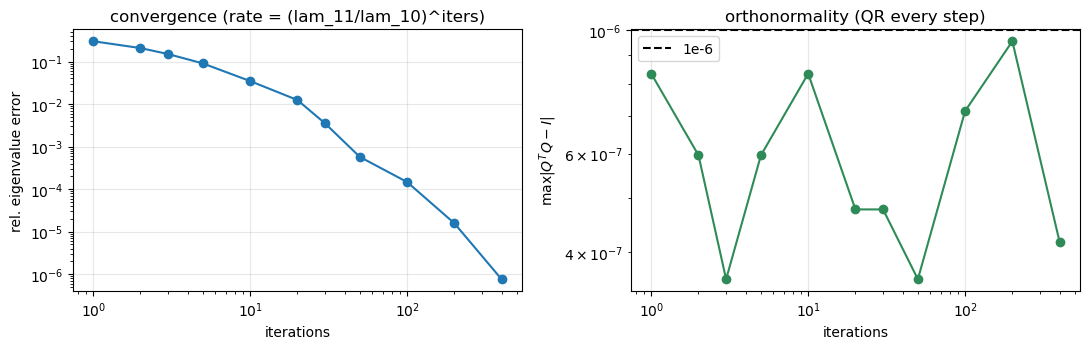

  orthonormality is ~1e-7 at EVERY iteration count: QR enforces it structurally.


In [22]:
print("convergence of orthogonal iteration vs iteration count (d=100, k=10)")
its = [1, 2, 3, 5, 10, 20, 30, 50, 100, 200, 400]
errs, orths = [], []
w_ref = jnp.linalg.eigh(Gk)[0][::-1][:10]
for it in its:
    lam, Q = compute_topk_eigs(lambda v: Gk @ v, 100, 10, it, RNGKey(0))
    errs.append(float(jnp.abs(lam - w_ref).max() / w_ref.max()))
    orths.append(float(jnp.abs(Q.T @ Q - jnp.eye(10)).max()))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].loglog(its, errs, 'o-'); ax[0].set(xlabel="iterations", ylabel="rel. eigenvalue error",
                                         title="convergence (rate = (lam_11/lam_10)^iters)")
ax[0].grid(alpha=.3)
ax[1].loglog(its, orths, 'o-', color='seagreen')
ax[1].axhline(1e-6, ls='--', c='k', label='1e-6')
ax[1].set(xlabel="iterations", ylabel=r"$\max|Q^TQ-I|$", title="orthonormality (QR every step)")
ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()
print(f"  orthonormality is ~1e-7 at EVERY iteration count: QR enforces it structurally.")

### 3.3 `mvp_power_iteration`

In [23]:
lam_ref = float(jnp.linalg.eigvalsh(Gk).max())
print(f"  true lambda_max = {lam_ref:.6f}")
for it in (3, 10, 50, 200):
    mu, v = mvp_power_iteration(lambda u: Gk @ u, 100, it, RNGKey(0))
    res = float(jnp.linalg.norm(Gk @ v - mu * v) / abs(mu))
    print(f"    it={it:4d}  mu={float(mu):10.6f}  rel.err={abs(float(mu)-lam_ref)/lam_ref:9.2e}  residual={res:.2e}")
gap = float(jnp.linalg.eigvalsh(Gk)[-2] / jnp.linalg.eigvalsh(Gk)[-1])
print(f"\n  lambda_2/lambda_1 = {gap:.4f}  ->  error after N iters ~ gap^N")
for N in (200, 1000, 4000):
    mu, _ = mvp_power_iteration(lambda u: Gk @ u, 100, N, RNGKey(0))
    print(f"    N={N:5d}  rel.err {abs(float(mu)-lam_ref)/lam_ref:9.2e}   gap^N = {gap**N:9.2e}")
mu, _ = mvp_power_iteration(lambda u: Gk @ u, 100, 1000, RNGKey(0))
check("power iteration converges to lambda_max (N=1000)",
      abs(float(mu) - lam_ref) / lam_ref, 1e-5)
print("\n  NOTE: power iteration converges from BELOW, so too few iterations")
print("        UNDERESTIMATES lambda_max and therefore OVERESTIMATES 2/lambda.")
print("        With a small spectral gap that needs ~1000 iterations, not 3.")

  true lambda_max = 10.000000


    it=   3  mu=  8.887891  rel.err= 1.11e-01  residual=1.24e-01
    it=  10  mu=  9.525065  rel.err= 4.75e-02  residual=3.86e-02
    it=  50  mu=  9.862828  rel.err= 1.37e-02  residual=9.89e-03
    it= 200  mu=  9.930341  rel.err= 6.97e-03  residual=4.69e-03

  lambda_2/lambda_1 = 0.9900  ->  error after N iters ~ gap^N
    N=  200  rel.err  6.97e-03   gap^N =  1.34e-01
    N= 1000  rel.err  9.54e-08   gap^N =  4.32e-05


    N= 4000  rel.err  9.54e-08   gap^N =  3.47e-18
  [PASS] power iteration converges to lambda_max (N=1000)       9.537e-08 <= 1e-05

  NOTE: power iteration converges from BELOW, so too few iterations
        UNDERESTIMATES lambda_max and therefore OVERESTIMATES 2/lambda.
        With a small spectral gap that needs ~1000 iterations, not 3.


### 3.4 `align_bases` and the permutation metrics

Known-answer tests: identical bases, a known permutation, and orthogonal bases.

In [24]:
Q1, _ = jnp.linalg.qr(jr.normal(jr.PRNGKey(20), (10, 4)))

a = align_bases(Q1, Q1)
print(f"  identical bases  : score={float(a['score']):.6f}  perm={np.asarray(a['perm'])}")
check("align_bases(Q,Q).score == 1", abs(float(a["score"]) - 1.0), 1e-5)
check("align_bases(Q,Q).perm == identity",
      float(jnp.abs(a["perm"] - jnp.arange(4)).max()), 1e-9)

perm = jnp.array([2, 0, 3, 1])
b = align_bases(Q1, Q1[:, perm])
inv = np.argsort(np.asarray(perm))
print(f"  applied to QB columns : {np.asarray(perm)}")
print(f"  align_bases returned  : {np.asarray(b['perm'])}")
print(f"  inverse of applied    : {inv}")
print()
print("  CONVENTION (this is correct behaviour, not a defect):")
print("    perm[i] = j  means  QA column i matches QB column j.")
print("    So if QB was built by permuting QA's columns by sigma, perm == sigma^-1,")
print("    because QA column i genuinely sits at QB position sigma^-1[i].")
ok = all(bool(jnp.allclose(Q1[:, i], Q1[:, perm][:, np.asarray(b["perm"])[i]], atol=1e-5))
         for i in range(4))
print(f"    direct check  QA[:,i] == QB[:,perm[i]]  for all i : {ok}")
check("align_bases perm maps QA-index -> QB-index",
      float(np.abs(np.asarray(b["perm"]) - inv).max()), 1e-9)

print()
print("  Does this convention affect perm_hamming(perm_t, perm_t+1)?  No.")
print("    d(p,q) = n - |fix(q^-1 p)| and d(p^-1,q^-1) = n - |fix(p q^-1)|;")
print("    q^-1 p and p q^-1 are conjugate, so same cycle type, same fixed points.")
import itertools as _it
_bad = sum(1 for _p in _it.permutations(range(4)) for _q in _it.permutations(range(4))
           if abs(float(perm_hamming(jnp.array(_p), jnp.array(_q)))
                  - float(perm_hamming(jnp.array(np.argsort(_p)), jnp.array(np.argsort(_q))))) > 1e-9)
print(f"    exhaustive check over all 576 pairs at n=4: mismatches = {_bad}")
check("perm_hamming is invariant under simultaneous inversion", float(_bad), 0.5)
print("    => the logged Perm Hamming metrics are unaffected by the convention.")
print("    It matters only for per-direction readouts: matched[i] is indexed by")
print("    QA's column (row of W), so index consistently when asking")
print("    'which true direction sits at which learned rank'.")
check("permuted score still 1", abs(float(b["score"]) - 1.0), 1e-5)

Qfull, _ = jnp.linalg.qr(jr.normal(jr.PRNGKey(21), (10, 8)))
c = align_bases(Qfull[:, :4], Qfull[:, 4:])
print(f"  orthogonal bases : score={float(c['score']):.2e}  (want ~0)")
check("orthogonal bases score ~ 0", float(c["score"]), 1e-8)

  identical bases  : score=1.000000  perm=[0 1 2 3]
  [PASS] align_bases(Q,Q).score == 1                            1.192e-07 <= 1e-05
  [PASS] align_bases(Q,Q).perm == identity                      0.000e+00 <= 1e-09


  applied to QB columns : [2 0 3 1]
  align_bases returned  : [1 3 0 2]
  inverse of applied    : [1 3 0 2]

  CONVENTION (this is correct behaviour, not a defect):
    perm[i] = j  means  QA column i matches QB column j.
    So if QB was built by permuting QA's columns by sigma, perm == sigma^-1,
    because QA column i genuinely sits at QB position sigma^-1[i].
    direct check  QA[:,i] == QB[:,perm[i]]  for all i : True
  [PASS] align_bases perm maps QA-index -> QB-index             0.000e+00 <= 1e-09

  Does this convention affect perm_hamming(perm_t, perm_t+1)?  No.
    d(p,q) = n - |fix(q^-1 p)| and d(p^-1,q^-1) = n - |fix(p q^-1)|;
    q^-1 p and p q^-1 are conjugate, so same cycle type, same fixed points.


    exhaustive check over all 576 pairs at n=4: mismatches = 0
  [PASS] perm_hamming is invariant under simultaneous inversion   0.000e+00 <= 5e-01
    => the logged Perm Hamming metrics are unaffected by the convention.
    It matters only for per-direction readouts: matched[i] is indexed by
    QA's column (row of W), so index consistently when asking
    'which true direction sits at which learned rank'.
  [PASS] permuted score still 1                                 1.192e-07 <= 1e-05


  orthogonal bases : score=9.07e-15  (want ~0)
  [PASS] orthogonal bases score ~ 0                             9.074e-15 <= 1e-08


True

In [25]:
print("orthonormality of align_bases inputs -- the documented PRECONDITION")
def orth_err(Q):
    return float(jnp.abs(Q.T @ Q - jnp.eye(Q.shape[1])).max())

Qgood, _ = jnp.linalg.qr(jr.normal(jr.PRNGKey(22), (100, 10)))
Qbad = Qgood.at[:, 3].set(Qgood[:, 3] + 0.05 * Qgood[:, 4])
print(f"  clean basis : max|Q^T Q - I| = {orth_err(Qgood):.2e}")
print(f"  perturbed   : max|Q^T Q - I| = {orth_err(Qbad):.2e}")
print("\n  align_bases does NOT check this. A score computed from non-orthonormal")
print("  columns is not a squared-cosine alignment. Worth logging orth_err per step.")
check("clean QR basis is orthonormal", orth_err(Qgood), 1e-5)

orthonormality of align_bases inputs -- the documented PRECONDITION
  clean basis : max|Q^T Q - I| = 3.58e-07
  perturbed   : max|Q^T Q - I| = 5.00e-02

  align_bases does NOT check this. A score computed from non-orthonormal
  columns is not a squared-cosine alignment. Worth logging orth_err per step.
  [PASS] clean QR basis is orthonormal                          3.576e-07 <= 1e-05


True

In [26]:
print("spectral distances on known spectra")
lam = jnp.array([4.0, 2.0, 1.0, 0.5])
print(f"  spectral_l2(lam, lam)   = {float(spectral_l2(lam, lam)):.3e}  (want 0)")
print(f"  spectral_kl(lam, lam)   = {float(spectral_kl(lam, lam)):.3e}  (want 0)")
print(f"  wasserstein_1d(lam,lam) = {float(wasserstein_1d(lam, lam)):.3e}  (want 0)")
check("spectral_l2 self-distance", float(spectral_l2(lam, lam)), 1e-6)
check("spectral_kl self-distance", abs(float(spectral_kl(lam, lam))), 1e-6)
check("wasserstein_1d self-distance", float(wasserstein_1d(lam, lam)), 1e-6)

print("\n  behaviour on a spectrum with structural zeros (rank-deficient Gram):")
W = jr.normal(jr.PRNGKey(30), (64, 100))
l1 = jnp.linalg.eigvalsh(W.T @ W / 64)
print(f"    {int((l1 < 0).sum())}/100 eigenvalues < 0, min = {float(l1.min()):.2e}")
print(f"    spectral_kl full     = {float(spectral_kl(l1, l1[::-1])):.6f}")
print(f"    spectral_kl top-64   = {float(spectral_kl(jnp.sort(l1)[::-1][:64], jnp.sort(l1[::-1])[::-1][:64])):.6f}")
print("    -> restrict spectral comparisons to the top-k (k <= rank).")

spectral distances on known spectra
  spectral_l2(lam, lam)   = 0.000e+00  (want 0)
  spectral_kl(lam, lam)   = 0.000e+00  (want 0)


  wasserstein_1d(lam,lam) = 0.000e+00  (want 0)
  [PASS] spectral_l2 self-distance                              0.000e+00 <= 1e-06
  [PASS] spectral_kl self-distance                              0.000e+00 <= 1e-06
  [PASS] wasserstein_1d self-distance                           0.000e+00 <= 1e-06

  behaviour on a spectrum with structural zeros (rank-deficient Gram):


    20/100 eigenvalues < 0, min = -8.38e-07
    spectral_kl full     = 13.361352
    spectral_kl top-64   = 0.000000
    -> restrict spectral comparisons to the top-k (k <= rank).


## 4. Autodiff operators

In [27]:
# shared small model for sections 4-6
n, d, r, m = 64, 3, 3, 64
rng = RNGKey(33)
X = jr.normal(rng.next(), (n, d))
U_t = stiefel(d, r, rng)
f_target = lambda x: poly(jnp.array([1.0, 1.3, 0.7]), jnp.array([3, 2, 1]),
                          U_t @ x, basis="hermite", normalize=True)
y = jax.vmap(f_target)(X) + 0.001 * jr.normal(rng.next(), (n,))

model = MLP([d, m, 1], parameterization='standard', rng=RNGKey(33))
state = TrainState.create(apply_fn=model.apply_fn, params=model.params,
                          update_fn=gd_update, parameterization='standard')
loss_fn = lambda o, t: 2 * l2_loss(o, t)
pf, unravel = ravel_pytree(state.params)
print(f"  model [d={d}, m={m}, 1], P = {pf.shape[0]} parameters")

  model [d=3, m=64, 1], P = 321 parameters


### 4.1 HVP vs dense Hessian

`_hvp_flat(params, apply_fn, loss_fn, X, y, v_flat)` — **positional, in signature order**.
`apply_fn` and `loss_fn` are `static_argnames`, so a traced array in either slot raises
`ValueError: Non-hashable static arguments`.

In [28]:
L_flat = lambda p: jnp.mean((jax.vmap(lambda x: model.apply_fn(unravel(p), x))(X) - y) ** 2)
H_dense = jax.hessian(L_flat)(pf)
print(f"  dense Hessian {H_dense.shape}")

v = jr.normal(jr.PRNGKey(40), (pf.shape[0],))
hv_dense = H_dense @ v
hv_flat  = _hvp_flat(state.params, state.apply_fn, loss_fn, X, y, v)
rel = float(jnp.linalg.norm(hv_flat - hv_dense) / jnp.linalg.norm(hv_dense))
print(f"  ||_hvp_flat(v) - H v|| / ||H v|| = {rel:.3e}")
check("_hvp_flat matches the dense Hessian", rel, 1e-4)

lam_dense = float(jnp.linalg.eigvalsh(H_dense).max())
lam_pi, _ = mvp_power_iteration(
    lambda u: _hvp_flat(state.params, state.apply_fn, loss_fn, X, y, u),
    pf.shape[0], 300, RNGKey(0))
print(f"  lambda_max: dense {lam_dense:.6f}   power iteration {float(lam_pi):.6f}")
check("Hessian lambda_max via power iteration", abs(float(lam_pi) - lam_dense) / abs(lam_dense), 1e-3)
print(f"\n  _hvp_flat jit cache entries: {_hvp_flat._cache_size()}  (want 1 -- no recompiles)")

  dense Hessian (321, 321)


  ||_hvp_flat(v) - H v|| / ||H v|| = 2.961e-07
  [PASS] _hvp_flat matches the dense Hessian                    2.961e-07 <= 1e-04


  lambda_max: dense 42.671913   power iteration 42.671902
  [PASS] Hessian lambda_max via power iteration                 2.682e-07 <= 1e-03

  _hvp_flat jit cache entries: 1  (want 1 -- no recompiles)


In [29]:
print("the argument-order trap")
try:
    _hvp_flat(state.params, v, X, y, apply_fn=state.apply_fn, loss_fn=loss_fn)
    print("  (no error)")
except Exception as e:
    print(f"  {type(e).__name__}: {str(e).splitlines()[0][:96]}")
print("  -> v landed in the apply_fn static slot. Pass all six positionally, in order.")

the argument-order trap
  ValueError: Non-hashable static arguments are not supported. An error occurred while trying to hash an objec
  -> v landed in the apply_fn static slot. Pass all six positionally, in order.


### 4.2 NTK MVP vs dense $JJ^\top/n$, and the Gauss-Newton factor of 2

In [30]:
fwd = lambda p: jax.vmap(lambda x: model.apply_fn(unravel(p), x))(X)
J = jax.jacrev(fwd)(pf)
K_dense = J @ J.T / n
print(f"  dense NTK {K_dense.shape}")

u = jr.normal(jr.PRNGKey(41), (n,))
Ku_dense = K_dense @ u
Ku_nvp   = nvp(state.params, model, X, u)
rel = float(jnp.linalg.norm(Ku_nvp - Ku_dense) / jnp.linalg.norm(Ku_dense))
print(f"  ||nvp(u) - K u|| / ||K u|| = {rel:.3e}")
check("nvp matches the dense NTK", rel, 1e-4)

lam_ntk = float(jnp.linalg.eigvalsh(K_dense).max())
print(f"\n  lambda_max(NTK)     = {lam_ntk:.4f}")
print(f"  lambda_max(Hessian) = {lam_dense:.4f}")
print(f"  ratio H/NTK         = {lam_dense/lam_ntk:.4f}")
print("  loss_fn = 2*l2_loss = (yhat-y)^2, so the Gauss-Newton Hessian is (2/n)J^T J")
print("  while nvp returns (1/n) J J^T  =>  lambda_max(H) = 2 lambda_max(K).")
check("Hessian / NTK ratio is 2", abs(lam_dense / lam_ntk - 2.0), 5e-2)
print(f"\n  => 2/lambda_max(NTK) = {2/lam_ntk:.6f} is TWICE the GD stability limit")
print(f"     2/lambda_max(H)    = {2/lam_dense:.6f} is the real critical lr")

  dense NTK (64, 64)
  ||nvp(u) - K u|| / ||K u|| = 1.184e-07
  [PASS] nvp matches the dense NTK                              1.184e-07 <= 1e-04



  lambda_max(NTK)     = 21.1753
  lambda_max(Hessian) = 42.6719
  ratio H/NTK         = 2.0152
  loss_fn = 2*l2_loss = (yhat-y)^2, so the Gauss-Newton Hessian is (2/n)J^T J
  while nvp returns (1/n) J J^T  =>  lambda_max(H) = 2 lambda_max(K).
  [PASS] Hessian / NTK ratio is 2                               1.518e-02 <= 5e-02

  => 2/lambda_max(NTK) = 0.094450 is TWICE the GD stability limit
     2/lambda_max(H)    = 0.046869 is the real critical lr


### 4.3 AGOP vs an explicit Jacobian

In [31]:
G = compute_agop(state, model, X)['layer1_agop']
J_x = jax.vmap(jax.grad(lambda x: model.apply_fn(state.params, x)))(X)
G_ref = J_x.T @ J_x / n
print(f"  layer1_agop {G.shape},  reference {G_ref.shape}")
rel = float(jnp.linalg.norm(G - G_ref) / jnp.linalg.norm(G_ref))
print(f"  relative difference = {rel:.3e}")
check("compute_agop layer1 == (1/n) sum grad_x f grad_x f^T", rel, 1e-5)

print(f"\n  layers returned by agop(): {sorted(compute_agop(state, model, X).keys())}")
print("  layer2_agop is m x m and is stored every step if not filtered -- the memory sink.")

print("\n  AGOP = W1^T D W1  with D = E[(a * phi')(a * phi')^T]:")
W1 = state.params[0]['weights']
acts = jax.vmap(lambda x: model.apply_fn(state.params, x, return_activations=True))(X)[1]
a_out = state.params[-1]['weights'][0]
dphi = (acts[1] > 0).astype(jnp.float32)
Dv = (a_out[None, :] * dphi)
D = Dv.T @ Dv / n
print(f"    ||W1^T D W1 - AGOP||/||AGOP|| = "
      f"{float(jnp.linalg.norm(W1.T @ D @ W1 - G)/jnp.linalg.norm(G)):.3e}")
print("    The NFA is exactly the claim that D is proportional to I on row(W1).")
print(f"    D anisotropy: std(diag)/mean(diag) = {float(jnp.std(jnp.diag(D))/jnp.mean(jnp.diag(D))):.3f}")

  layer1_agop (3, 3),  reference (3, 3)
  relative difference = 0.000e+00
  [PASS] compute_agop layer1 == (1/n) sum grad_x f grad_x f^T   0.000e+00 <= 1e-05

  layers returned by agop(): ['layer1_agop', 'layer2_agop']
  layer2_agop is m x m and is stored every step if not filtered -- the memory sink.

  AGOP = W1^T D W1  with D = E[(a * phi')(a * phi')^T]:


    ||W1^T D W1 - AGOP||/||AGOP|| = 1.873e-07
    The NFA is exactly the claim that D is proportional to I on row(W1).
    D anisotropy: std(diag)/mean(diag) = 1.306


## 5. Parametrization and a parametrization-aware `eta_crit`

`gd_update` applies a per-layer learning-rate scale. Under a non-standard parametrization the
update is $\theta \leftarrow \theta - \eta S\nabla L$, so the error propagates as
$(I - \eta S H)$ and the stability condition becomes

$$\eta\,\lambda_{\max}\!\left(S^{1/2} H S^{1/2}\right) < 2$$

**not** $\eta\lambda_{\max}(H) < 2$. So `eta_crit` computed from the raw Hessian or NTK is
only valid for `standard`.

In [32]:
def lr_scale_vector(model_params, parameterization):
    """Per-PARAMETER lr scale, flattened to ravel_pytree order -- mirrors gd_update."""
    sc, Lp = [], len(model_params)
    for i, p in enumerate(model_params):
        fo, fi = p['weights'].shape
        if parameterization == 'standard':  lw, lb = 1.0, 1.0
        elif parameterization == 'ntk':     lw, lb = 1.0 / fi, 1.0
        elif parameterization == 'mup':
            lw = float(fo) if i == 0 else (1.0 / fi if i == Lp - 1 else 1.0)
            lb = float(fo)
        elif parameterization == 'spectral': lw, lb = fo / fi, 1.0
        else: raise ValueError(parameterization)
        sc.append({'weights': jnp.full_like(p['weights'], lw),
                   'bias':    jnp.full_like(p['bias'], lb)})
    return ravel_pytree(sc)[0]


def eta_crit_preconditioned(state, loss_fn, X, y, parameterization, iters=300, key=0):
    """2 / lambda_max(S^{1/2} H S^{1/2}) -- the stability limit UNDER this parametrization."""
    pflat, _ = ravel_pytree(state.params)
    rs = jnp.sqrt(lr_scale_vector(state.params, parameterization))
    mvp = lambda v: rs * _hvp_flat(state.params, state.apply_fn, loss_fn, X, y, rs * v)
    lam, _ = mvp_power_iteration(mvp, pflat.shape[0], iters, RNGKey(key))
    return 2.0 / float(lam), float(lam)


print(f"  unpreconditioned 2/lambda_max(H) = {2/lam_dense:.6f}\n")
print(f"  {'parametrization':14s} {'lam(S^1/2 H S^1/2)':>20s} {'eta_crit':>12s} {'vs standard':>12s}")
base = None
for pz in ('standard', 'ntk', 'mup', 'spectral'):
    ec, lam = eta_crit_preconditioned(state, loss_fn, X, y, pz)
    if base is None: base = ec
    print(f"  {pz:14s} {lam:20.3f} {ec:12.6f} {ec/base:11.1f}x")
print("\n  These span orders of magnitude, so a single scalar lr cannot serve all of them.")
print("  Report lr as eta/eta_crit(parametrization) to compare across them.")

  unpreconditioned 2/lambda_max(H) = 0.046869

  parametrization   lam(S^1/2 H S^1/2)     eta_crit  vs standard


  standard                     42.672     0.046869         1.0x
  ntk                           3.252     0.615009        13.1x


  mup                          76.533     0.026132         0.6x
  spectral                     18.391     0.108751         2.3x

  These span orders of magnitude, so a single scalar lr cannot serve all of them.
  Report lr as eta/eta_crit(parametrization) to compare across them.


In [33]:
print("gd_update scales, and the anti-inversion guard")
for pz in ('standard', 'ntk', 'mup', 'spectral'):
    ps = [{'weights': jnp.zeros((4096, 100)), 'bias': jnp.zeros((4096,))},
          {'weights': jnp.zeros((1, 4096)),   'bias': jnp.zeros((1,))}]
    gs = [{k: jnp.ones_like(v) for k, v in p.items()} for p in ps]
    new = gd_update(ps, gs, 1.0, parameterization=pz)
    s0 = -float(new[0]['weights'][0, 0]); s1 = -float(new[-1]['weights'][0, 0])
    print(f"  {pz:10s} input-layer scale {s0:12.6f}   output-layer scale {s1:12.6f}   ratio {s0/s1:12.1f}")

ps = [{'weights': jnp.zeros((4096, 100)), 'bias': jnp.zeros((4096,))},
      {'weights': jnp.zeros((1, 4096)),   'bias': jnp.zeros((1,))}]
gs = [{k: jnp.ones_like(v) for k, v in p.items()} for p in ps]
mu = gd_update(ps, gs, 1.0, parameterization='mup')
ratio = float(mu[0]['weights'][0,0]) / float(mu[-1]['weights'][0,0])
print(f"\n  muP input/output ratio at [100, 4096, 1]: {ratio:.1f}  (want fan_out^2 = {4096**2})")
check("muP lr scales are not transposed", abs(ratio - 4096**2) / 4096**2, 1e-6)

gd_update scales, and the anti-inversion guard


  standard   input-layer scale     1.000000   output-layer scale     1.000000   ratio          1.0
  ntk        input-layer scale     0.010000   output-layer scale     0.000244   ratio         41.0
  mup        input-layer scale  4096.000000   output-layer scale     0.000244   ratio   16777216.0
  spectral   input-layer scale    40.959999   output-layer scale     0.000244   ratio     167772.2

  muP input/output ratio at [100, 4096, 1]: 16777216.0  (want fan_out^2 = 16777216)
  [PASS] muP lr scales are not transposed                       0.000e+00 <= 1e-06


True

## 6. End-to-end smoke test

In [34]:
from metrics import compute_metrics
from nn_utils import neuron_sparsity
from opt import train

num_power_iters = 30
metrics_config = {
    "agop":       {"fn": compute_agop,       "args": (model, X)},
    "nfm":        {"fn": compute_nfm},
    "agop_eigs":  {"fn": compute_agop_eigs,  "args": (model, X, r, rng, num_power_iters)},
    "nfm_eigs":   {"fn": compute_nfm_eigs,   "args": (r, rng, num_power_iters)},
    "sparsity":   {"fn": neuron_sparsity,    "args": (model, X)},
}

st = TrainState.create(apply_fn=model.apply_fn, params=model.params,
                       update_fn=gd_update, parameterization='standard')
ec, _ = eta_crit_preconditioned(st, loss_fn, X, y, 'standard')
print(f"  training 40 steps at 0.5 * eta_crit = {0.5*ec:.6f}")
st, traj, mets = train(st, loss_fn, X, y, lr=0.5*ec, steps=40, metrics_config=metrics_config)

print(f"\n  len(traj)={len(traj)}  len(loss)={len(mets['loss'])}")
check("traj and loss have the same length", abs(len(traj) - len(mets['loss'])), 0.5)

for nm in ('agop_eigs', 'nfm_eigs'):
    ev = jnp.stack(mets[nm]['eigvecs'])
    oe = float(jnp.abs(jnp.einsum('tij,tik->tjk', ev, ev) - jnp.eye(r)).max())
    print(f"  {nm}: eigvecs {ev.shape}  worst orthonormality over trajectory {oe:.2e}")
    check(f"{nm} eigenvectors stay orthonormal", oe, 1e-4)

lo = jnp.array(mets['loss'])
print(f"  loss {float(lo[0]):.4f} -> {float(lo[-1]):.4f}   all finite: {bool(jnp.all(jnp.isfinite(lo)))}")
check("loss decreased", float(lo[0] - lo[-1]), 0.0, higher_is_better=True)
check("all losses finite", 0.0 if bool(jnp.all(jnp.isfinite(lo))) else 1.0, 0.5)

  training 40 steps at 0.5 * eta_crit = 0.023435



  0%|          | 0/40 [00:00<?, ?it/s]

Box(children=(HTML(value="<table style='background:#1e1e1e; width:100%; border-collapse:collapse'></table>"),)…


  0%|          | 0/40 [00:00<?, ?it/s, loss=4.64, update=0.105s]


  2%|▎         | 1/40 [00:00<00:22,  1.73it/s, loss=4.64, update=0.105s]

...


100%|██████████| 40/40 [00:06<00:00,  7.16it/s, loss=1.15, update=0.000s]


100%|██████████| 40/40 [00:06<00:00,  6.44it/s, loss=1.15, update=0.000s]


  len(traj)=41  len(loss)=41
  [PASS] traj and loss have the same length                     0.000e+00 <= 5e-01
  agop_eigs: eigvecs (41, 3, 3)  worst orthonormality over trajectory 4.17e-07
  [PASS] agop_eigs eigenvectors stay orthonormal                4.172e-07 <= 1e-04
  nfm_eigs: eigvecs (41, 3, 3)  worst orthonormality over trajectory 5.96e-07
  [PASS] nfm_eigs eigenvectors stay orthonormal                 5.960e-07 <= 1e-04


  loss 4.6429 -> 1.1426   all finite: True
  [PASS] loss decreased                                         3.500e+00 >= 0e+00
  [PASS] all losses finite                                      0.000e+00 <= 5e-01


True

alignment against the ground-truth AGOP (not against U directly)


  G* spectrum: [3.7355 3.1873 0.4181]


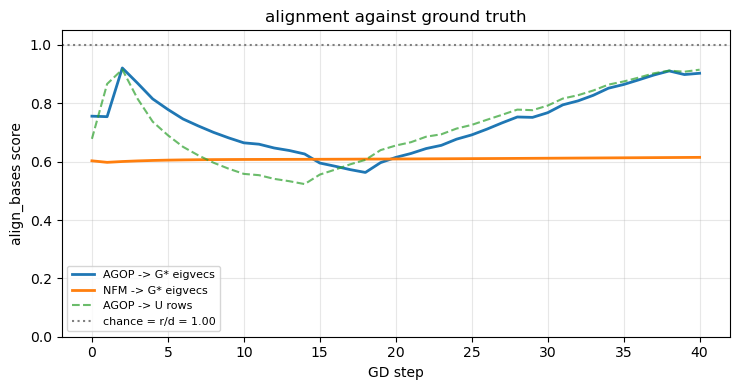

  chance level r/d = 1.000  -- at d=r this is 1.0 and the metric has NO headroom


In [35]:
print("alignment against the ground-truth AGOP (not against U directly)")
G_star = np.asarray(target_agop_empirical(f_target, X))
w_s, V_s = np.linalg.eigh(G_star); V_s = V_s[:, ::-1][:, :r]; w_s = w_s[::-1][:r]
print(f"  G* spectrum: {np.round(w_s, 4)}")

ag_e = jnp.stack(mets['agop_eigs']['eigvecs'])
nf_e = jnp.stack(mets['nfm_eigs']['eigvecs'])
a_to_star = [float(align_bases(ag_e[t], jnp.asarray(V_s))['score']) for t in range(ag_e.shape[0])]
n_to_star = [float(align_bases(nf_e[t], jnp.asarray(V_s))['score']) for t in range(nf_e.shape[0])]
a_to_U    = [float(align_bases(ag_e[t], U_t.T)['score']) for t in range(ag_e.shape[0])]

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(a_to_star, label="AGOP -> G* eigvecs", lw=2)
ax.plot(n_to_star, label="NFM -> G* eigvecs", lw=2)
ax.plot(a_to_U, '--', label="AGOP -> U rows", alpha=.7)
ax.axhline(r / d, color='grey', ls=':', label=f"chance = r/d = {r/d:.2f}")
ax.set(xlabel="GD step", ylabel="align_bases score", ylim=(0, 1.05),
       title="alignment against ground truth")
ax.legend(fontsize=8); ax.grid(alpha=.3); plt.tight_layout(); plt.show()
print(f"  chance level r/d = {r/d:.3f}  -- at d=r this is 1.0 and the metric has NO headroom")

In [36]:
summary()


54/54 passed


True